In [ ]:
pip show numpy scipy

In [ ]:
pip install h3

In [ ]:
pip install seaborn

In [ ]:
pip install --upgrade numpy scipy

In [ ]:
pip install --upgrade --force-reinstall numpy==1.24.3 pandas scipy matplotlib

In [7]:
pip show osmnx

Name: osmnx
Version: 2.0.5
Summary: Download, model, analyze, and visualize street networks and other geospatial features from OpenStreetMap
Home-page: 
Author: Geoff Boeing
Author-email: Geoff Boeing <boeing@usc.edu>
License-Expression: MIT
Location: /home/sriya/anaconda3/envs/cdp-gis/lib/python3.10/site-packages
Requires: geopandas, networkx, numpy, pandas, requests, shapely
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [2]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np

# Test OSMnx
G = ox.graph_from_place("Manhattan, New York, USA", network_type='drive', simplify=True)
print("Success! Network has", len(G.nodes()), "nodes and", len(G.edges()), "edges.")

Success! Network has 4622 nodes and 9908 edges.


In [3]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, LineString, Polygon
import matplotlib.pyplot as plt
import h3
import matplotlib.colors as mcolors
from scipy.stats import pearsonr
import json  # Add this line
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Download and prepare the street network
place_name = "Manhattan, New York, USA"
G = ox.graph_from_place(place_name, network_type='drive', simplify=True)
G_projected = ox.project_graph(G)

print("Libraries imported and street network downloaded successfully!")

Libraries imported and street network downloaded successfully!


In [4]:
# Load from the existing JSON file
with open('/home/sriya/mapping/cdp-mapping-systems/Assignments/assignment4/manhattan_landmarks.json', 'r') as f:
    landmarks = json.load(f)

# Convert to GeoDataFrame
df = pd.DataFrame.from_dict(landmarks, orient='index')
geometry = [Point(row['longitude'], row['latitude']) for _, row in df.iterrows()]
landmarks_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Reset index to make the landmark names a column
landmarks_gdf = landmarks_gdf.reset_index().rename(columns={'index': 'name'})

# Display the landmarks
print(f"Loaded {len(landmarks_gdf)} landmarks:")
print("Available columns:", landmarks_gdf.columns.tolist())

# Now you can access the columns correctly
landmarks_gdf[['name', 'category', 'geometry']]

Loaded 6 landmarks:
Available columns: ['name', 'address', 'year_built', 'height_meters', 'floors', 'architect', 'category', 'latitude', 'longitude', 'year_established', 'area_sq_meters', 'annual_visitors_millions', 'designers', 'geometry']


,name,category,geometry
0,Empire State Building,Skyscraper,POINT (-73.9853 40.74865)
1,Times Square,Public Square,POINT (-73.95989 40.78962)
2,Central Park,Urban Park,POINT (-74.00602 40.71273)
3,One World Trade Center,Skyscraper,POINT (-74.01304 40.71295)
4,Rockefeller Center,Commercial Complex,POINT (-73.97996 40.75926)
5,Metropolitan Museum of Art,Museum,POINT (-73.96338 40.77944)


In [5]:
# Add Columbia University
landmarks["Columbia University"] = {
    "address": "116th St & Broadway, New York, NY 10027",
    "year_established": 1754,
    "category": "University",
    "latitude": 40.8075,
    "longitude": -73.9626
}

In [6]:
# Convert to DataFrame first, then add geometry
df = pd.DataFrame.from_dict(landmarks, orient='index')
geometry = [Point(row['longitude'], row['latitude']) for _, row in df.iterrows()]
pois_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [7]:
def plot_poi_network(G, pois_gdf):
    """Plot a street network with points of interest and their labels."""
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(15, 15))
    
    # Plot the street network
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.5, 
                 edge_color='lightgray', show=False, close=False)
    
    # Project POIs to the same CRS as the graph
    pois_proj = pois_gdf.to_crs(G.graph['crs'])
    
    # Plot POIs with a larger marker
    pois_proj.plot(ax=ax, color='red', markersize=100, marker='*', 
                  label='Landmarks', zorder=3)
    
    # Add labels to each POI with better formatting
    for x, y, label in zip(pois_proj.geometry.x, pois_proj.geometry.y, pois_proj.index):
        ax.annotate(
            text=label,
            xy=(x, y),
            xytext=(5, 5),  # Offset from point
            textcoords='offset points',
            fontsize=9,
            bbox=dict(
                boxstyle='round,pad=0.3',
                fc='white',
                alpha=0.8,
                edgecolor='none'
            ),
            zorder=4  # Make sure labels appear above markers
        )
    
    # Add legend and title
    plt.legend(markerscale=0.7)  # Make legend marker smaller
    plt.title("Manhattan Street Network with Landmarks", pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()

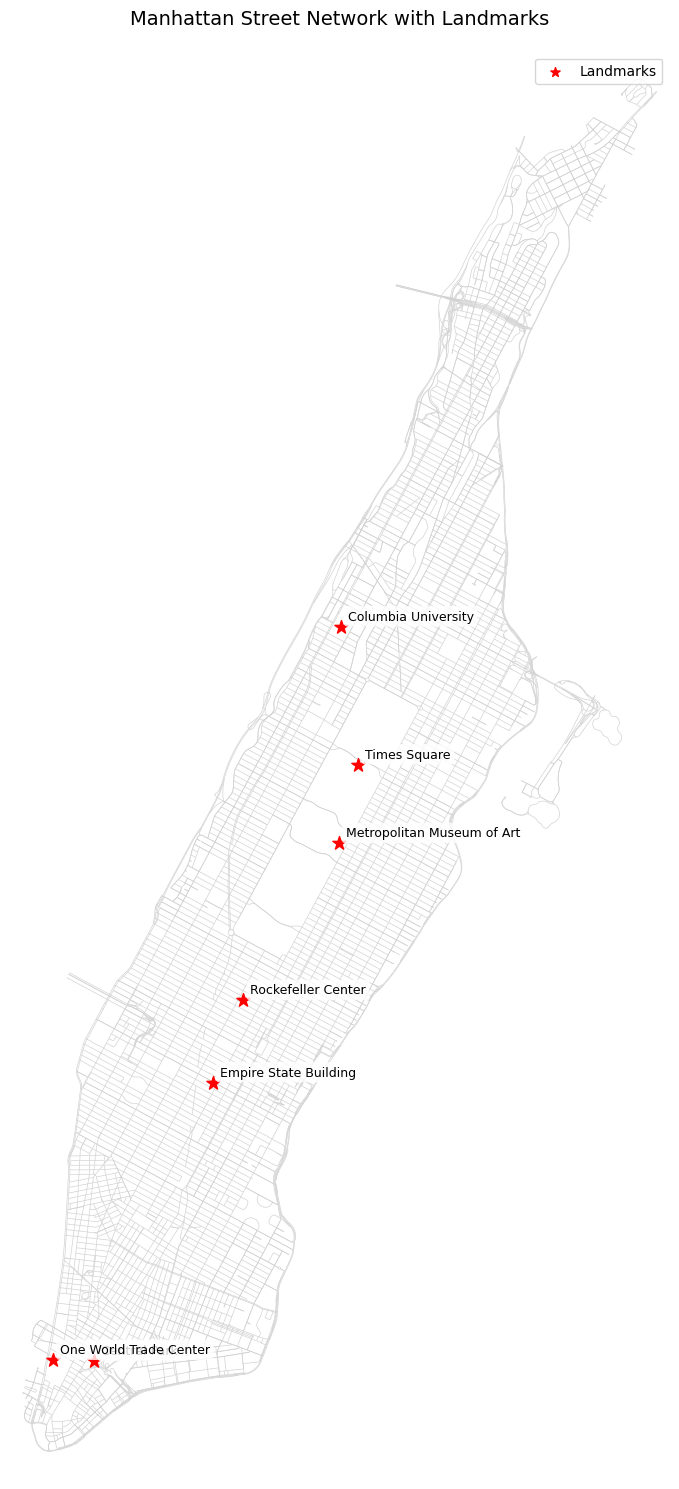

In [8]:
# 4. Call the function to visualize
plot_poi_network(G_projected, pois_gdf)

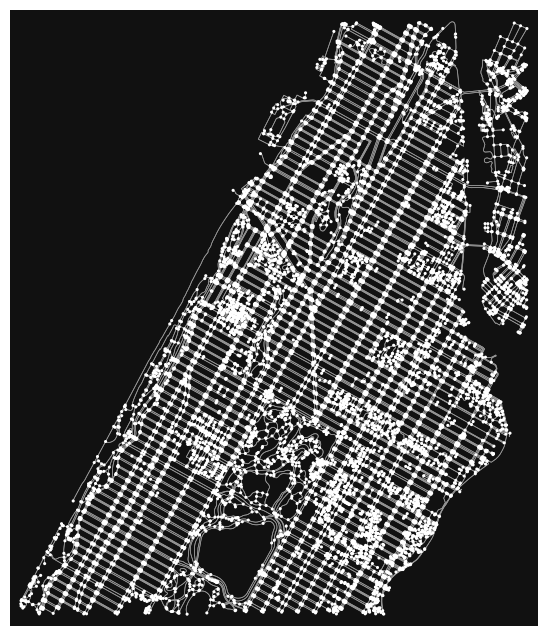

In [ ]:
# Get network around Columbia University (using coordinates)
columbia_point = (40.8075, -73.9626)  # Columbia University coordinates
mh_network = ox.graph_from_point(columbia_point, dist=3000, network_type="walk")  # 3000m radius

# To visualize
fig, ax = ox.plot_graph(mh_network, node_size=5, edge_linewidth=0.5)

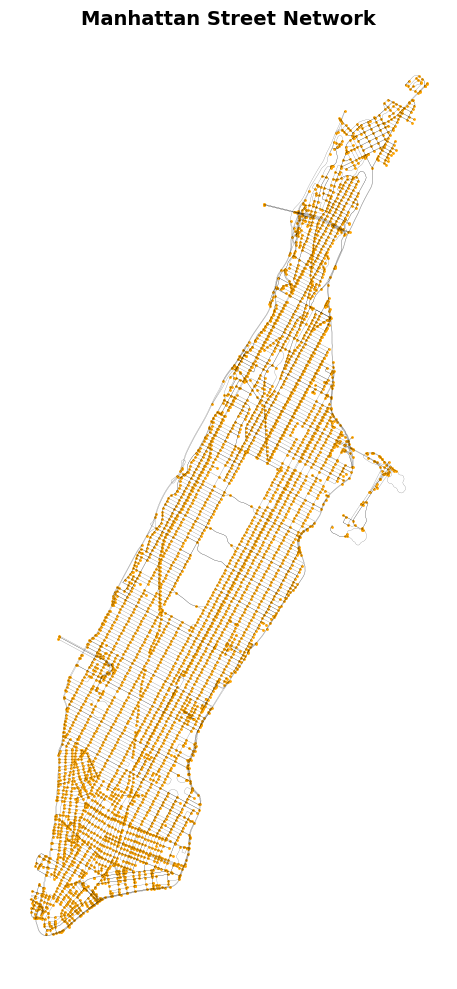

In [11]:
# First, ensure you have the street network data
place_name = "Manhattan, New York, USA"
G = ox.graph_from_place(place_name, network_type='drive', simplify=True)
G_projected = ox.project_graph(G)

# Get nodes and edges as GeoDataFrames
mh_net_nodes, mh_net_edges = ox.graph_to_gdfs(G_projected, nodes=True, edges=True)

# Now plot with your specified style
ax = mh_net_edges.plot(color="black", linewidth=0.1, figsize=(10, 10))
mh_net_nodes.plot(ax=ax, color="orange", markersize=1).set_axis_off()

# Add title and show plot
plt.title("Manhattan Street Network", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
mh_network

In [13]:
# 2. Load and prepare landmarks data
with open('/home/sriya/mapping/cdp-mapping-systems/Assignments/assignment4/manhattan_landmarks.json', 'r') as f:
    landmarks = json.load(f)

# Add Columbia University
landmarks["Columbia University"] = {
    "address": "116th St & Broadway, New York, NY 10027",
    "year_established": 1754,
    "category": "University",
    "latitude": 40.8075,
    "longitude": -73.9626
}


In [14]:
# Convert to GeoDataFrame
df = pd.DataFrame.from_dict(landmarks, orient='index')
geometry = [Point(row['longitude'], row['latitude']) for _, row in df.iterrows()]
pois_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [15]:
# 3. Project the GeoDataFrame to match the network's CRS
pois_proj = pois_gdf.to_crs(G_projected.graph['crs'])

# 4. Find nearest network nodes for each point
pois_proj['nearest_node'] = pois_proj['geometry'].apply(
    lambda x: ox.distance.nearest_nodes(G_projected, x.x, x.y)
)

In [16]:
def calculate_euclidean_distances(gdf):
    coords = np.column_stack((gdf.geometry.x, gdf.geometry.y))
    dist_matrix = squareform(pdist(coords))
    return pd.DataFrame(
        dist_matrix,
        index=gdf.index,
        columns=gdf.index
    )

def calculate_network_distances(G, gdf):
    nodes = gdf['nearest_node'].values
    n = len(nodes)
    dist_matrix = np.zeros((n, n))
    
    for i in tqdm(range(n), desc="Calculating network distances"):
        for j in range(i+1, n):
            try:
                path = nx.shortest_path_length(
                    G, 
                    nodes[i], 
                    nodes[j], 
                    weight='length'
                )
                dist_matrix[i, j] = path
                dist_matrix[j, i] = path
            except nx.NetworkXNoPath:
                dist_matrix[i, j] = np.nan
                dist_matrix[j, i] = np.nan
    
    return pd.DataFrame(
        dist_matrix,
        index=gdf.index,
        columns=gdf.index
    )

In [17]:
# Check the structure of pois_gdf
print("Columns in pois_gdf:", pois_gdf.columns.tolist())
print("\nFirst few rows of pois_gdf:")
print(pois_gdf.head())

# Check if 'name' column exists, if not, use the index
if 'name' not in pois_gdf.columns:
    print("\n'name' column not found. Using index for landmark names.")
    pois_gdf['name'] = pois_gdf.index

# Now try finding nearest nodes
print("\nFinding nearest network nodes...")
pois_gdf['nearest_node'] = pois_gdf['geometry'].apply(
    lambda x: ox.distance.nearest_nodes(G_projected, x.x, x.y)
)

# Print the results using the correct column name
print("\nNearest nodes found for each landmark:")
if 'name' in pois_gdf.columns:
    print(pois_gdf[['name', 'nearest_node']].head())
else:
    print(pois_gdf[['nearest_node']].head())

Columns in pois_gdf: ['address', 'year_built', 'height_meters', 'floors', 'architect', 'category', 'latitude', 'longitude', 'year_established', 'area_sq_meters', 'annual_visitors_millions', 'designers', 'geometry']

First few rows of pois_gdf:
                                                         address  year_built  \
Empire State Building           20 W 34th St, New York, NY 10001      1931.0   
Times Square                                 Manhattan, NY 10036         NaN   
Central Park                                  New York, NY 10024         NaN   
One World Trade Center         285 Fulton St, New York, NY 10007      2014.0   
Rockefeller Center      45 Rockefeller Plaza, New York, NY 10111      1939.0   

                        height_meters  floors              architect  \
Empire State Building           381.0   102.0  Shreve, Lamb & Harmon   
Times Square                      NaN     NaN                    NaN   
Central Park                      NaN     NaN              

In [18]:
import sys
print(sys.executable)
!{sys.executable} -m pip install tqdm --user

/home/sriya/anaconda3/envs/cdp-gis/bin/python


In [20]:
from tqdm.auto import tqdm
print("tqdm imported successfully!")

tqdm imported successfully!


/home/sriya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:

# Reset the index to make the landmark names a column
pois_gdf = pois_gdf.reset_index().rename(columns={'index': 'name'})

# Convert to proper geometry if needed
if not isinstance(pois_gdf.geometry, gpd.GeoSeries):
    pois_gdf['geometry'] = gpd.points_from_xy(pois_gdf.longitude, pois_gdf.latitude)
    pois_gdf = gpd.GeoDataFrame(pois_gdf, geometry='geometry', crs="EPSG:4326")

# Project to match the network's CRS
pois_proj = pois_gdf.to_crs(G_projected.graph['crs'])

# Find nearest nodes
print("Finding nearest network nodes...")
pois_proj['nearest_node'] = pois_proj['geometry'].apply(
    lambda x: ox.distance.nearest_nodes(G_projected, x.x, x.y)
)

# Verify
print("\nNearest nodes found for each landmark:")
print(pois_proj[['name', 'nearest_node']].head())

# Now calculate distances
print("\nCalculating Euclidean distances...")
euclidean_dist = calculate_euclidean_distances(pois_proj)

print("\nCalculating network distances (this may take a few minutes)...")
network_dist = calculate_network_distances(G_projected, pois_proj)

Finding nearest network nodes...

Nearest nodes found for each landmark:
  name                    name                    name  nearest_node
0    0   Empire State Building   Empire State Building      42437644
1    1            Times Square            Times Square      42443263
2    2            Central Park            Central Park    2821304146
3    3  One World Trade Center  One World Trade Center      42453395
4    4      Rockefeller Center      Rockefeller Center      42430356

Calculating Euclidean distances...

Calculating network distances (this may take a few minutes)...


Calculating network distances: 100%|██████████| 7/7 [00:00<00:00, 23.05it/s]


In [23]:
# 7. Compare Euclidean vs Network distances
def plot_distance_comparison(euclidean, network):
    # Flatten the distance matrices
    euclidean_flat = euclidean.values.flatten()
    network_flat = network.values.flatten()
    
    # Remove zeros (distance to self)
    mask = (euclidean_flat > 0) & (network_flat > 0)
    euclidean_flat = euclidean_flat[mask]
    network_flat = network_flat[mask]
    
    # Calculate ratio
    ratio = network_flat / euclidean_flat
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot
    ax1.scatter(euclidean_flat, network_flat, alpha=0.6)
    ax1.plot([0, network_flat.max()], [0, network_flat.max()], 'r--')
    ax1.set_xlabel('Euclidean Distance (m)')
    ax1.set_ylabel('Network Distance (m)')
    ax1.set_title('Euclidean vs Network Distance')
    
    # Ratio histogram
    sns.histplot(ratio, bins=30, kde=True, ax=ax2)
    ax2.axvline(ratio.mean(), color='r', linestyle='--')
    ax2.set_xlabel('Network Distance / Euclidean Distance')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of Distance Ratios')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Mean ratio (network/euclidean): {ratio.mean():.2f}")
    print(f"Median ratio: {np.median(ratio):.2f}")
    print(f"Minimum ratio: {ratio.min():.2f}")
    print(f"Maximum ratio: {ratio.max():.2f}")


In [24]:
# 8. Network analysis metrics (Xin et al. 2022)
def calculate_network_metrics(G, gdf):
    # Calculate network metrics
    metrics = {}
    
    # 1. Network density
    metrics['density'] = nx.density(G)
    
    # 2. Average shortest path length
    metrics['avg_shortest_path'] = nx.average_shortest_path_length(
        G, weight='length'
    )
    
    # 3. Global efficiency
    metrics['global_efficiency'] = nx.global_efficiency(G)
    
    # 4. Local efficiency
    metrics['local_efficiency'] = nx.local_efficiency(G)
    
    # 5. Node centrality
    betweenness = nx.betweenness_centrality(G, weight='length')
    metrics['avg_betweenness'] = np.mean(list(betweenness.values()))
    
    # 6. Path circuity (network/euclidean)
    path_circuity = []
    nodes = gdf['nearest_node'].values
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            try:
                path = nx.shortest_path_length(
                    G, nodes[i], nodes[j], weight='length'
                )
                # Get node coordinates
                x1, y1 = G.nodes[nodes[i]]['x'], G.nodes[nodes[i]]['y']
                x2, y2 = G.nodes[nodes[j]]['x'], G.nodes[nodes[j]]['y']
                # Calculate euclidean distance
                euclidean = np.sqrt((x2-x1)**2 + (y2-y1)**2)
                if euclidean > 0:
                    path_circuity.append(path / euclidean)
            except:
                continue
                
    metrics['avg_path_circuity'] = np.mean(path_circuity)
    
    return metrics

In [25]:
# 9. Plot network with paths
def plot_network_with_paths(G, gdf, origin_name="Columbia University"):
    # Get origin node
    origin_node = gdf.loc[origin_name, 'nearest_node']
    
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 12))
    
    # Plot base network
    ox.plot_graph(
        G, 
        ax=ax, 
        node_size=0, 
        edge_linewidth=0.5, 
        edge_color='lightgray',
        show=False
    )
    
    # Plot paths from origin to each destination
    for _, row in gdf[gdf.index != origin_name].iterrows():
        try:
            path = nx.shortest_path(
                G, 
                origin_node, 
                row['nearest_node'], 
                weight='length'
            )
            ox.plot_graph_route(
                G, 
                path, 
                ax=ax, 
                route_linewidth=2,
                route_alpha=0.7,
                show=False,
                close=False
            )
        except:
            continue
    
    # Plot points
    gdf.plot(
        ax=ax, 
        color='red', 
        markersize=100, 
        marker='*',
        label='Landmarks'
    )
    
    # Add labels
    for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf.index):
        ax.annotate(
            label, 
            xy=(x, y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="white",
                alpha=0.8
            )
        )
    
    plt.title(f"Paths from {origin_name} to Landmarks", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [26]:
# Calculate distance matrices
print("Calculating Euclidean distances...")
euclidean_dist = calculate_euclidean_distances(pois_gdf)

print("\nCalculating network distances (this may take a few minutes)...")
network_dist = calculate_network_distances(G_projected, pois_gdf)

# Verify the network distance matrix
print("\nNetwork distance matrix sample:")
print(network_dist.head())

Calculating Euclidean distances...

Calculating network distances (this may take a few minutes)...


Calculating network distances: 100%|██████████| 7/7 [00:00<00:00, 24966.10it/s]


Network distance matrix sample:
     0    1    2    3    4    5    6
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [27]:
# Debug information
print("CRS of network:", G_projected.graph['crs'])
print("CRS of points:", pois_gdf.crs)
print("Columns in pois_gdf:", pois_gdf.columns.tolist())
print("\nFirst few points:")
print(pois_gdf[['name', 'geometry']].head())

CRS of network: EPSG:32618
CRS of points: EPSG:4326
Columns in pois_gdf: ['name', 'name', 'address', 'year_built', 'height_meters', 'floors', 'architect', 'category', 'latitude', 'longitude', 'year_established', 'area_sq_meters', 'annual_visitors_millions', 'designers', 'geometry', 'name', 'nearest_node']

First few points:
  name                    name                    name  \
0    0   Empire State Building   Empire State Building   
1    1            Times Square            Times Square   
2    2            Central Park            Central Park   
3    3  One World Trade Center  One World Trade Center   
4    4      Rockefeller Center      Rockefeller Center   

                     geometry  
0   POINT (-73.9853 40.74865)  
1  POINT (-73.95989 40.78962)  
2  POINT (-74.00602 40.71273)  
3  POINT (-74.01304 40.71295)  
4  POINT (-73.97996 40.75926)  


In [28]:
def calculate_network_metrics(G, gdf):
    metrics = {}
    
    # Work with the largest strongly connected component
    if G.is_directed():
        G_undirected = G.to_undirected()
    else:
        G_undirected = G.copy()
    
    # Get largest connected component
    largest_cc = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G_undirected.subgraph(largest_cc).copy()
    
    # 1. Network density
    metrics['density'] = nx.density(G_lcc)
    
    # 2. Average shortest path length (only for connected components)
    try:
        metrics['avg_shortest_path'] = nx.average_shortest_path_length(
            G_lcc, weight='length'
        )
    except nx.NetworkXError:
        metrics['avg_shortest_path'] = float('nan')
    
    # 3. Global efficiency
    metrics['global_efficiency'] = nx.global_efficiency(G_lcc)
    
    # 4. Local efficiency
    metrics['local_efficiency'] = nx.local_efficiency(G_lcc)
    
    # 5. Node centrality (on largest connected component)
    try:
        betweenness = nx.betweenness_centrality(G_lcc, weight='length')
        metrics['avg_betweenness'] = np.mean(list(betweenness.values()))
    except:
        metrics['avg_betweenness'] = float('nan')
    
    # 6. Path circuity (only for reachable pairs)
    path_circuity = []
    nodes = gdf['nearest_node'].values
    nodes = [n for n in nodes if n in G_lcc]
    
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            try:
                path = nx.shortest_path_length(
                    G_lcc, nodes[i], nodes[j], weight='length'
                )
                # Get node coordinates
                x1, y1 = G_lcc.nodes[nodes[i]]['x'], G_lcc.nodes[nodes[i]]['y']
                x2, y2 = G_lcc.nodes[nodes[j]]['x'], G_lcc.nodes[nodes[j]]['y']
                # Calculate euclidean distance
                euclidean = np.sqrt((x2-x1)**2 + (y2-y1)**2)
                if euclidean > 0:
                    path_circuity.append(path / euclidean)
            except:
                continue
                
    metrics['avg_path_circuity'] = np.mean(path_circuity) if path_circuity else float('nan')
    
    # 7. Additional metrics
    metrics['n_components'] = nx.number_connected_components(G_undirected)
    metrics['n_nodes'] = G_lcc.number_of_nodes()
    metrics['n_edges'] = G_lcc.number_of_edges()
    
    return metrics

In [30]:
pip install geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.0-py3-none-any.whl.metadata (1.4 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.0-py3-none-any.whl (40 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopy]
Note: you may need to restart the kernel to use updated packages.


In [31]:

from geopy.distance import geodesic
# Create the GeoDataFrame
data = {
    'name': [
        'Empire State Building',
        'Times Square',
        'Central Park',
        'One World Trade Center',
        'Rockefeller Center',
        'Metropolitan Museum of Art'
    ],
    'category': [
        'Skyscraper',
        'Public Square',
        'Urban Park',
        'Skyscraper',
        'Commercial Complex',
        'Museum'
    ],
    'geometry': [
        Point(-73.9853, 40.74865),    # Empire State
        Point(-73.95989, 40.78962),   # Times Square
        Point(-74.00602, 40.71273),   # Central Park
        Point(-74.01304, 40.71295),   # One WTC
        Point(-73.97996, 40.75926),   # Rockefeller
        Point(-73.96338, 40.77944)    # Met Museum
    ]
}

gdf = gpd.GeoDataFrame(data, crs="EPSG:4326")

# Function to calculate distance between two points in meters
def calculate_distance(row1, row2):
    coords1 = (row1.geometry.y, row1.geometry.x)
    coords2 = (row2.geometry.y, row2.geometry.x)
    return geodesic(coords1, coords2).meters

# Create a matrix of distances
n = len(gdf)
distance_matrix = np.zeros((n, n))
names = gdf['name'].values

for i in range(n):
    for j in range(n):
        if i != j:
            distance_matrix[i, j] = calculate_distance(gdf.iloc[i], gdf.iloc[j])

# Create a DataFrame with the results
distances = pd.DataFrame(
    distance_matrix,
    index=gdf['name'],
    columns=gdf['name']
)

# Convert to km and round to 2 decimal places
distances_km = (distances / 1000).round(2)

print("Distance Matrix (km):")
display(distances_km)

# Get the closest pairs
print("\nClosest Pairs:")
for i in range(n):
    for j in range(i+1, n):
        print(f"{gdf['name'][i]} <-> {gdf['name'][j]}: {distances_km.iloc[i,j]} km")

# Optional: Save to CSV
distances_km.to_csv('landmark_distances_km.csv')

Distance Matrix (km):


name,Empire State Building,Times Square,Central Park,One World Trade Center,Rockefeller Center,Metropolitan Museum of Art
name,,,,,,
Empire State Building,0.00,5.03,4.36,4.61,1.26,3.89
Times Square,5.03,0.00,9.39,9.62,3.77,1.17
Central Park,4.36,9.39,0.00,0.59,5.62,8.24
One World Trade Center,4.61,9.62,0.59,0.00,5.85,8.49
Rockefeller Center,1.26,3.77,5.62,5.85,0.00,2.64
Metropolitan Museum of Art,3.89,1.17,8.24,8.49,2.64,0.00



Closest Pairs:
Empire State Building <-> Times Square: 5.03 km
Empire State Building <-> Central Park: 4.36 km
Empire State Building <-> One World Trade Center: 4.61 km
Empire State Building <-> Rockefeller Center: 1.26 km
Empire State Building <-> Metropolitan Museum of Art: 3.89 km
Times Square <-> Central Park: 9.39 km
Times Square <-> One World Trade Center: 9.62 km
Times Square <-> Rockefeller Center: 3.77 km
Times Square <-> Metropolitan Museum of Art: 1.17 km
Central Park <-> One World Trade Center: 0.59 km
Central Park <-> Rockefeller Center: 5.62 km
Central Park <-> Metropolitan Museum of Art: 8.24 km
One World Trade Center <-> Rockefeller Center: 5.85 km
One World Trade Center <-> Metropolitan Museum of Art: 8.49 km
Rockefeller Center <-> Metropolitan Museum of Art: 2.64 km


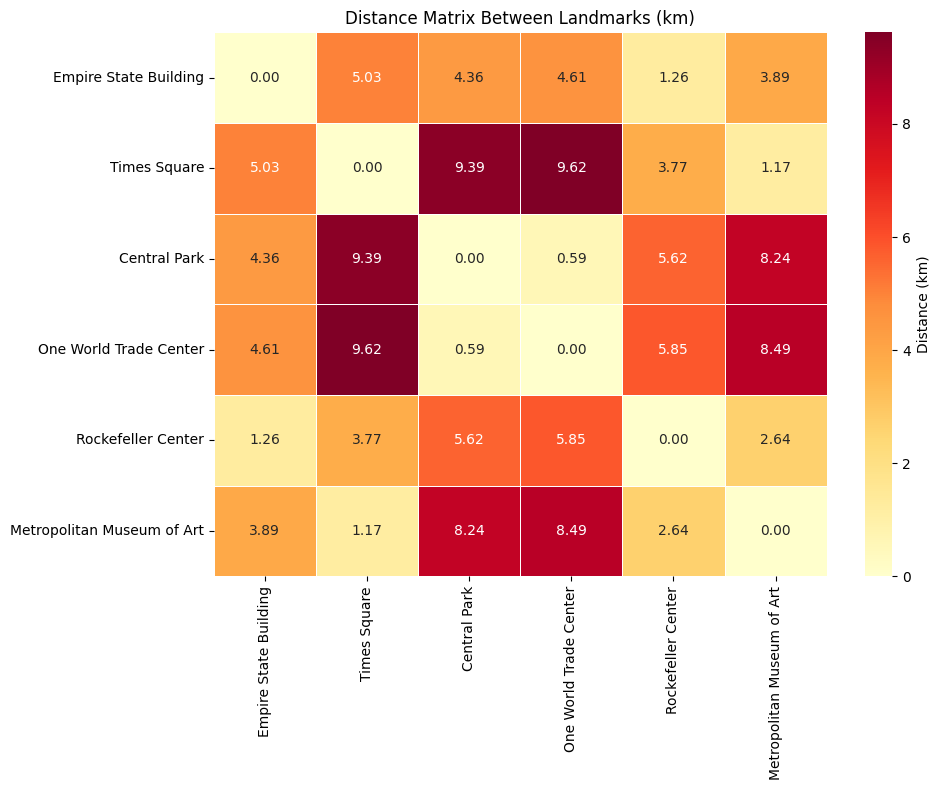

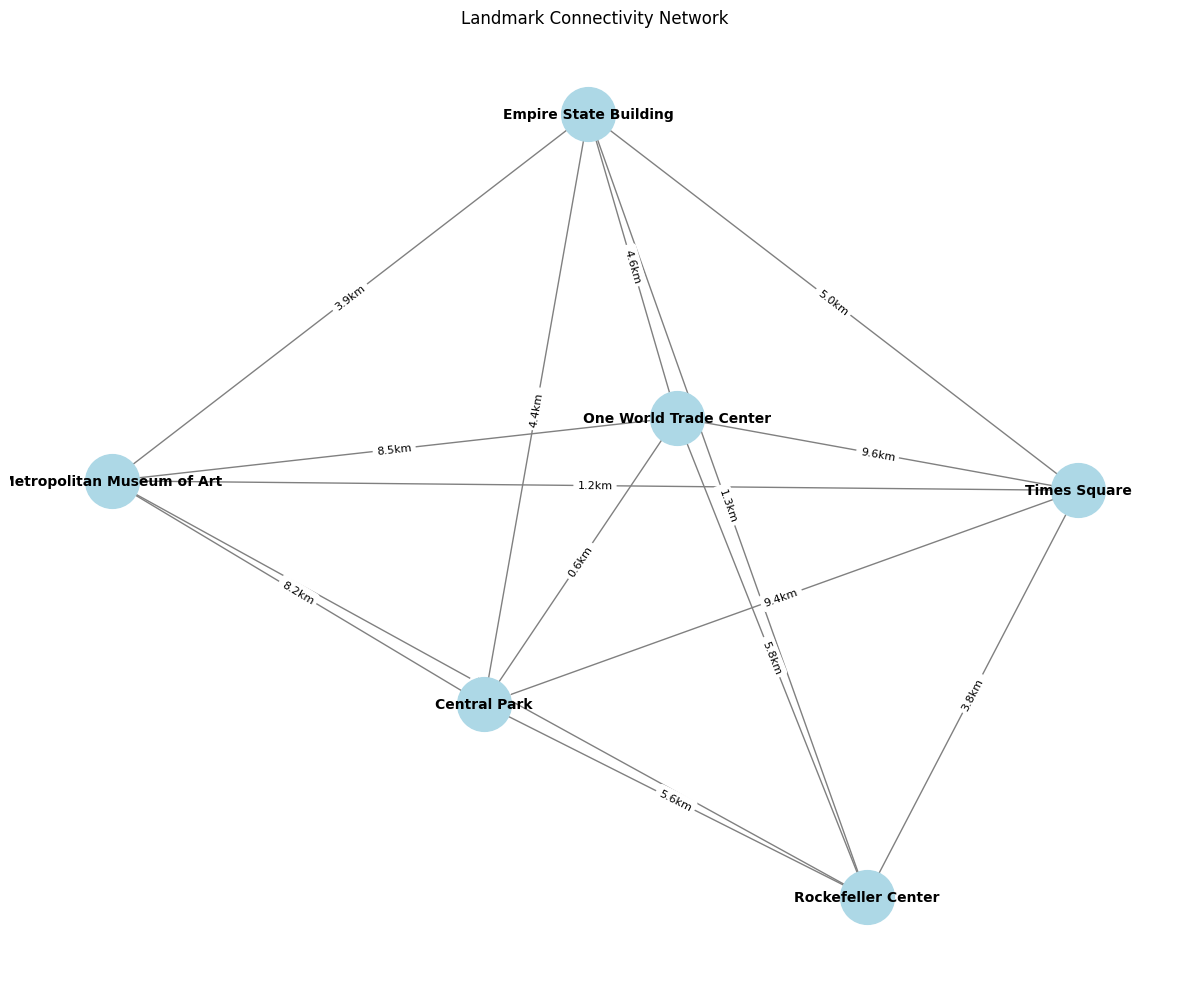


=== Network Analysis ===
Network Density: 1.0000
Average Shortest Path Length: 4.97 km

Degree Centrality:
  Empire State Building: 1.000
  Times Square: 1.000
  Central Park: 1.000
  One World Trade Center: 1.000
  Rockefeller Center: 1.000
  Metropolitan Museum of Art: 1.000

Betweenness Centrality:
  Rockefeller Center: 0.200
  Empire State Building: 0.100
  Times Square: 0.000
  Central Park: 0.000
  One World Trade Center: 0.000
  Metropolitan Museum of Art: 0.000

Closeness Centrality (higher is more central):
  Rockefeller Center: 0.261
  Empire State Building: 0.261
  Metropolitan Museum of Art: 0.205
  Central Park: 0.177
  Times Square: 0.173
  One World Trade Center: 0.171

=== Additional Network Metrics ===
Network Diameter: 9.62 km
Network Radius: 5.03 km
Network Center: ['Empire State Building']


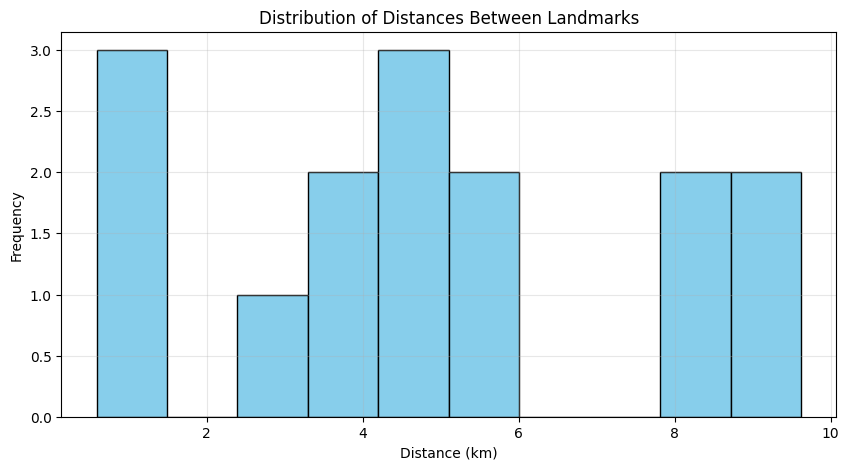

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Create the distance matrix
data = {
    'Empire State Building': [0.00, 5.03, 4.36, 4.61, 1.26, 3.89],
    'Times Square': [5.03, 0.00, 9.39, 9.62, 3.77, 1.17],
    'Central Park': [4.36, 9.39, 0.00, 0.59, 5.62, 8.24],
    'One World Trade Center': [4.61, 9.62, 0.59, 0.00, 5.85, 8.49],
    'Rockefeller Center': [1.26, 3.77, 5.62, 5.85, 0.00, 2.64],
    'Metropolitan Museum of Art': [3.89, 1.17, 8.24, 8.49, 2.64, 0.00]
}
dist_matrix = pd.DataFrame(data, index=data.keys())

# 1. Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, annot=True, cmap='YlOrRd', fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': 'Distance (km)'})
plt.title('Distance Matrix Between Landmarks (km)')
plt.tight_layout()
plt.show()

# 2. Network Graph
G = nx.Graph()

# Add nodes
for location in dist_matrix.columns:
    G.add_node(location)

# Add edges with weights
for i, loc1 in enumerate(dist_matrix.columns):
    for j, loc2 in enumerate(dist_matrix.columns):
        if i < j:  # Avoid duplicate edges and self-loops
            G.add_edge(loc1, loc2, weight=dist_matrix.loc[loc1, loc2])

# Calculate node positions using spring layout
pos = nx.spring_layout(G, weight='weight', seed=42)

# Draw the network
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=1, edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, 
    edge_labels={(u, v): f"{d['weight']:.1f}km" 
                for u, v, d in G.edges(data=True)},
    font_size=8)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title('Landmark Connectivity Network')
plt.axis('off')
plt.tight_layout()
plt.show()

# 3. Quantitative Analysis (Inspired by Xin et al. 2022)
print("\n=== Network Analysis ===")

# Calculate network density
density = nx.density(G)
print(f"Network Density: {density:.4f}")

# Calculate average shortest path length
avg_path_length = nx.average_shortest_path_length(G, weight='weight')
print(f"Average Shortest Path Length: {avg_path_length:.2f} km")

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)
print("\nDegree Centrality:")
for node, centrality in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

# Calculate betweenness centrality
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
print("\nBetweenness Centrality:")
for node, centrality in sorted(betweenness.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

# Calculate closeness centrality
closeness = nx.closeness_centrality(G, distance='weight')
print("\nCloseness Centrality (higher is more central):")
for node, centrality in sorted(closeness.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {centrality:.3f}")

# 4. Additional Metrics
print("\n=== Additional Network Metrics ===")
print(f"Network Diameter: {nx.diameter(G, weight='weight'):.2f} km")
print(f"Network Radius: {nx.radius(G, weight='weight'):.2f} km")
print(f"Network Center: {nx.center(G, weight='weight')}")

# 5. Histogram of Distances
plt.figure(figsize=(10, 5))
distances = [d['weight'] for u, v, d in G.edges(data=True)]
plt.hist(distances, bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distances Between Landmarks')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
import osmnx as ox
import networkx as nx
from shapely.geometry import Point
import numpy as np
import pandas as pd
import folium

# Function to calculate shortest path using road network
def calculate_shortest_path(gdf, source_idx):
    # Get graph for Manhattan area
    G = ox.graph_from_place("Manhattan, New York, USA", network_type="walk")

    results = []
    source_point = gdf.iloc[source_idx].geometry
    source_node = ox.nearest_nodes(G, source_point.x, source_point.y)

    for idx, row in gdf.iterrows():
        if idx != source_idx:
            target_point = row.geometry
            target_node = ox.nearest_nodes(G, target_point.x, target_point.y)
            length = nx.shortest_path_length(G, source_node, target_node, weight='length')
            path = nx.shortest_path(G, source_node, target_node, weight='length')
            results.append({
                'Landmark': row['name'],
                'Category': row['category'],
                'Distance (km)': length / 1000,
                'Path': path
            })
    return results, G

# Add Columbia University
columbia = {
    'name': 'Columbia University',
    'category': 'University',
    'geometry': Point(-73.9626, 40.8075)
}

columbia_row = pd.DataFrame([columbia])
gdf_with_columbia = pd.concat([gdf, columbia_row], ignore_index=True)

# Calculate shortest paths
columbia_idx = gdf_with_columbia[gdf_with_columbia['name'] == 'Columbia University'].index[0]
results, G = calculate_shortest_path(gdf_with_columbia, columbia_idx)

# Create map
m_columbia = folium.Map(location=[40.78, -73.97], zoom_start=13)

# Add markers
for idx, row in gdf_with_columbia.iterrows():
    icon_color = 'blue' if row['name'] == 'Columbia University' else 'red'
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=8,
        color=icon_color,
        fill=True,
        fill_color=icon_color,
        fill_opacity=0.7,
        popup=f"<b>{row['name']}</b><br>{row['category']}"
    ).add_to(m_columbia)

# Add routes
for r in results:
    route_nodes = r['Path']
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route_nodes]
    folium.PolyLine(
        route_coords,
        color='green',
        weight=3,
        opacity=0.7,
        tooltip=f"{r['Landmark']}: {r['Distance (km)']:.2f} km"
    ).add_to(m_columbia)

# Distance table
distances_df = pd.DataFrame(results).sort_values('Distance (km)')
display(distances_df[['Landmark', 'Category', 'Distance (km)']])

# Show map
m_columbia


,Landmark,Category,Distance (km)
1,Times Square,Public Square,2.537342
5,Metropolitan Museum of Art,Museum,3.919437
4,Rockefeller Center,Commercial Complex,6.129866
0,Empire State Building,Skyscraper,7.406085
3,One World Trade Center,Skyscraper,11.740106
2,Central Park,Urban Park,11.872279


In [36]:
# Add this inside your path plotting loop
for idx, landmark in gdf.iterrows():
    try:
        landmark_point = (landmark.geometry.x, landmark.geometry.y)
        print(f"\nProcessing: {landmark['name']} at {landmark_point}")
        
        landmark_node = ox.distance.nearest_nodes(G, landmark_point[0], landmark_point[1])
        print(f"Found nearest node: {landmark_node}")
        
        path = nx.shortest_path(G, columbia_node, landmark_node, weight='length')
        print(f"Path found with {len(path)} nodes")
        
        # Rest of your plotting code...
        
    except Exception as e:
        print(f"Error with {landmark['name']}: {str(e)}")


Processing: Empire State Building at (-73.9853, 40.74865)
Found nearest node: 701654214
Path found with 1 nodes

Processing: Times Square at (-73.95989, 40.78962)
Found nearest node: 701654214
Path found with 1 nodes

Processing: Central Park at (-74.00602, 40.71273)
Found nearest node: 701654214
Path found with 1 nodes

Processing: One World Trade Center at (-74.01304, 40.71295)
Found nearest node: 701654214
Path found with 1 nodes

Processing: Rockefeller Center at (-73.97996, 40.75926)
Found nearest node: 701654214
Path found with 1 nodes

Processing: Metropolitan Museum of Art at (-73.96338, 40.77944)
Found nearest node: 701654214
Path found with 1 nodes


In [41]:
# Project Columbia's coordinates to match the graph's CRS
columbia_point_geom = gpd.GeoDataFrame(
    geometry=[Point(columbia_point)], 
    crs="EPSG:4326"  # WGS84
).to_crs(graph_crs).geometry[0]

# Get the nearest node in the graph to our projected point
columbia_node = ox.distance.nearest_nodes(
    G, 
    columbia_point_geom.x, 
    columbia_point_geom.y
)

# Update the plotting code to use the projected coordinates
ax.scatter(
    columbia_point_geom.x, 
    columbia_point_geom.y, 
    c='red', 
    s=100, 
    label='Columbia University'
)

In [42]:
# Debug: Print the coordinates
print(f"Original Columbia coords (lon, lat): {columbia_point}")
print(f"Projected Columbia coords (x, y): {columbia_point_geom.x}, {columbia_point_geom.y}")
print(f"Nearest node coords: {G.nodes[columbia_node]['x']}, {G.nodes[columbia_node]['y']}")

Original Columbia coords (lon, lat): (-73.9626, 40.8075)
Projected Columbia coords (x, y): 587500.9789992092, 4517905.80879171
Nearest node coords: 587497.7508439837, 4517892.025818814


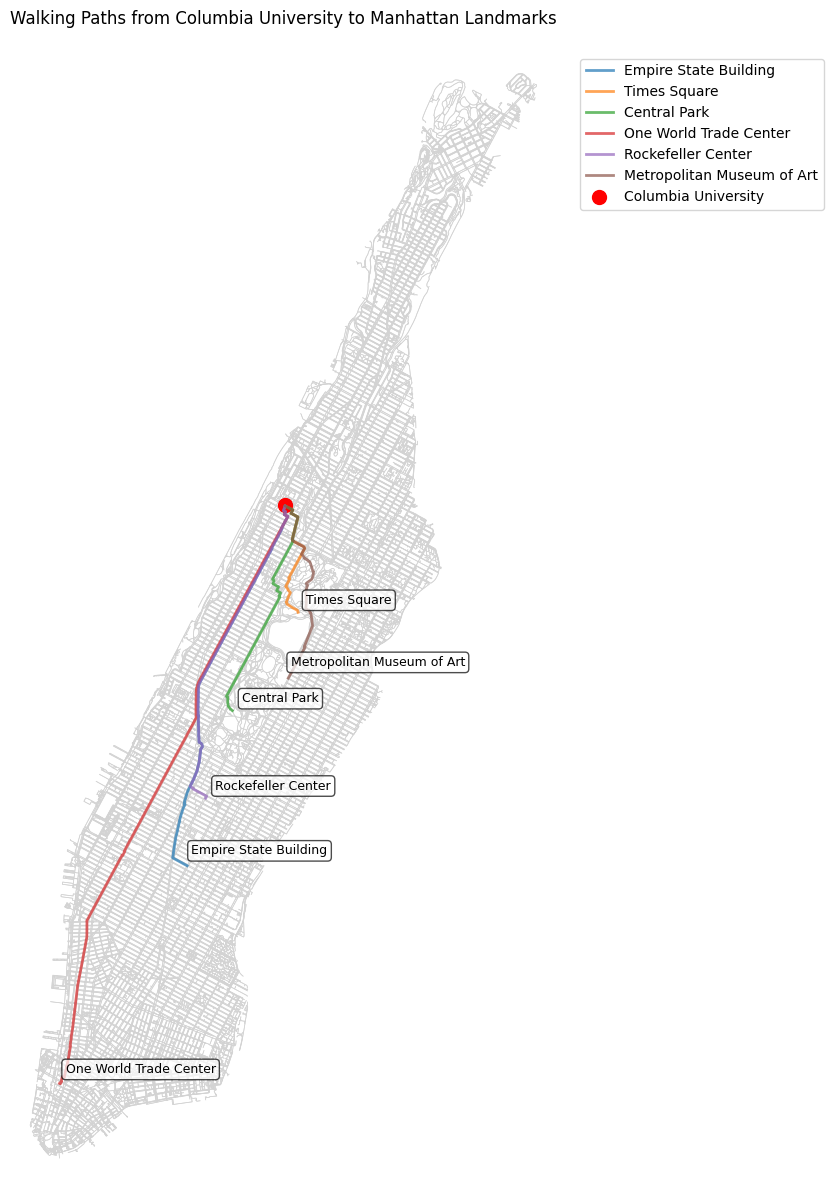

In [43]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# Configure OSMnx
ox.settings.log_console = True
ox.settings.use_cache = True

# Define origin (Columbia University) as (lon, lat)
columbia_point = (-73.9626, 40.8075)

# Get Manhattan street network
print("Downloading Manhattan street network...")
G = ox.graph_from_place("Manhattan, New York, USA", network_type='walk', simplify=True)
G_projected = ox.project_graph(G)
graph_crs = ox.graph_to_gdfs(G_projected, edges=False).crs

# Create landmarks with (lon, lat)
landmarks = {
    'name': [
        'Empire State Building',
        'Times Square',
        'Central Park',
        'One World Trade Center',
        'Rockefeller Center',
        'Metropolitan Museum of Art'
    ],
    'geometry': [
        Point(-73.9853, 40.74865),    # Empire State
        Point(-73.95989, 40.78962),   # Times Square
        Point(-73.97399, 40.77357),   # Central Park
        Point(-74.01304, 40.71295),   # One WTC
        Point(-73.97996, 40.75926),   # Rockefeller
        Point(-73.96338, 40.77944)    # Met Museum
    ]
}

# Create GeoDataFrame and project to graph's CRS
gdf = gpd.GeoDataFrame(landmarks, crs="EPSG:4326")
gdf_proj = gdf.to_crs(graph_crs)

# Project Columbia's point
columbia_geom = gpd.GeoDataFrame(
    geometry=[Point(columbia_point)], 
    crs="EPSG:4326"
).to_crs(graph_crs).geometry[0]

# Get nearest nodes
columbia_node = ox.distance.nearest_nodes(
    G_projected, 
    columbia_geom.x, 
    columbia_geom.y
)

# Create figure
fig, ax = plt.subplots(figsize=(15, 12))
ox.plot_graph(G_projected, ax=ax, show=False, close=False, 
             node_size=0, edge_linewidth=0.5, 
             edge_color='lightgray', bgcolor='white')

# Plot paths
for idx, row in gdf_proj.iterrows():
    try:
        # Get nearest node for landmark
        landmark_node = ox.distance.nearest_nodes(
            G_projected, 
            row.geometry.x, 
            row.geometry.y
        )
        
        # Get shortest path
        path = nx.shortest_path(
            G_projected, 
            columbia_node, 
            landmark_node, 
            weight='length'
        )
        
        # Plot path
        path_coords = [(G_projected.nodes[n]['x'], G_projected.nodes[n]['y']) for n in path]
        ax.plot(
            [p[0] for p in path_coords], 
            [p[1] for p in path_coords], 
            linewidth=2, 
            alpha=0.7, 
            label=row['name']
        )
        
        # Add label
        ax.annotate(
            row['name'], 
            xy=(row.geometry.x, row.geometry.y),
            xytext=(5, 5), 
            textcoords='offset points',
            fontsize=9, 
            ha='left', 
            va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
        )
        
    except Exception as e:
        print(f"Could not find path to {row['name']}: {e}")

# Plot Columbia point
ax.scatter(
    columbia_geom.x, 
    columbia_geom.y, 
    c='red', 
    s=100, 
    label='Columbia University'
)

# Add legend and title
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Walking Paths from Columbia University to Manhattan Landmarks", pad=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

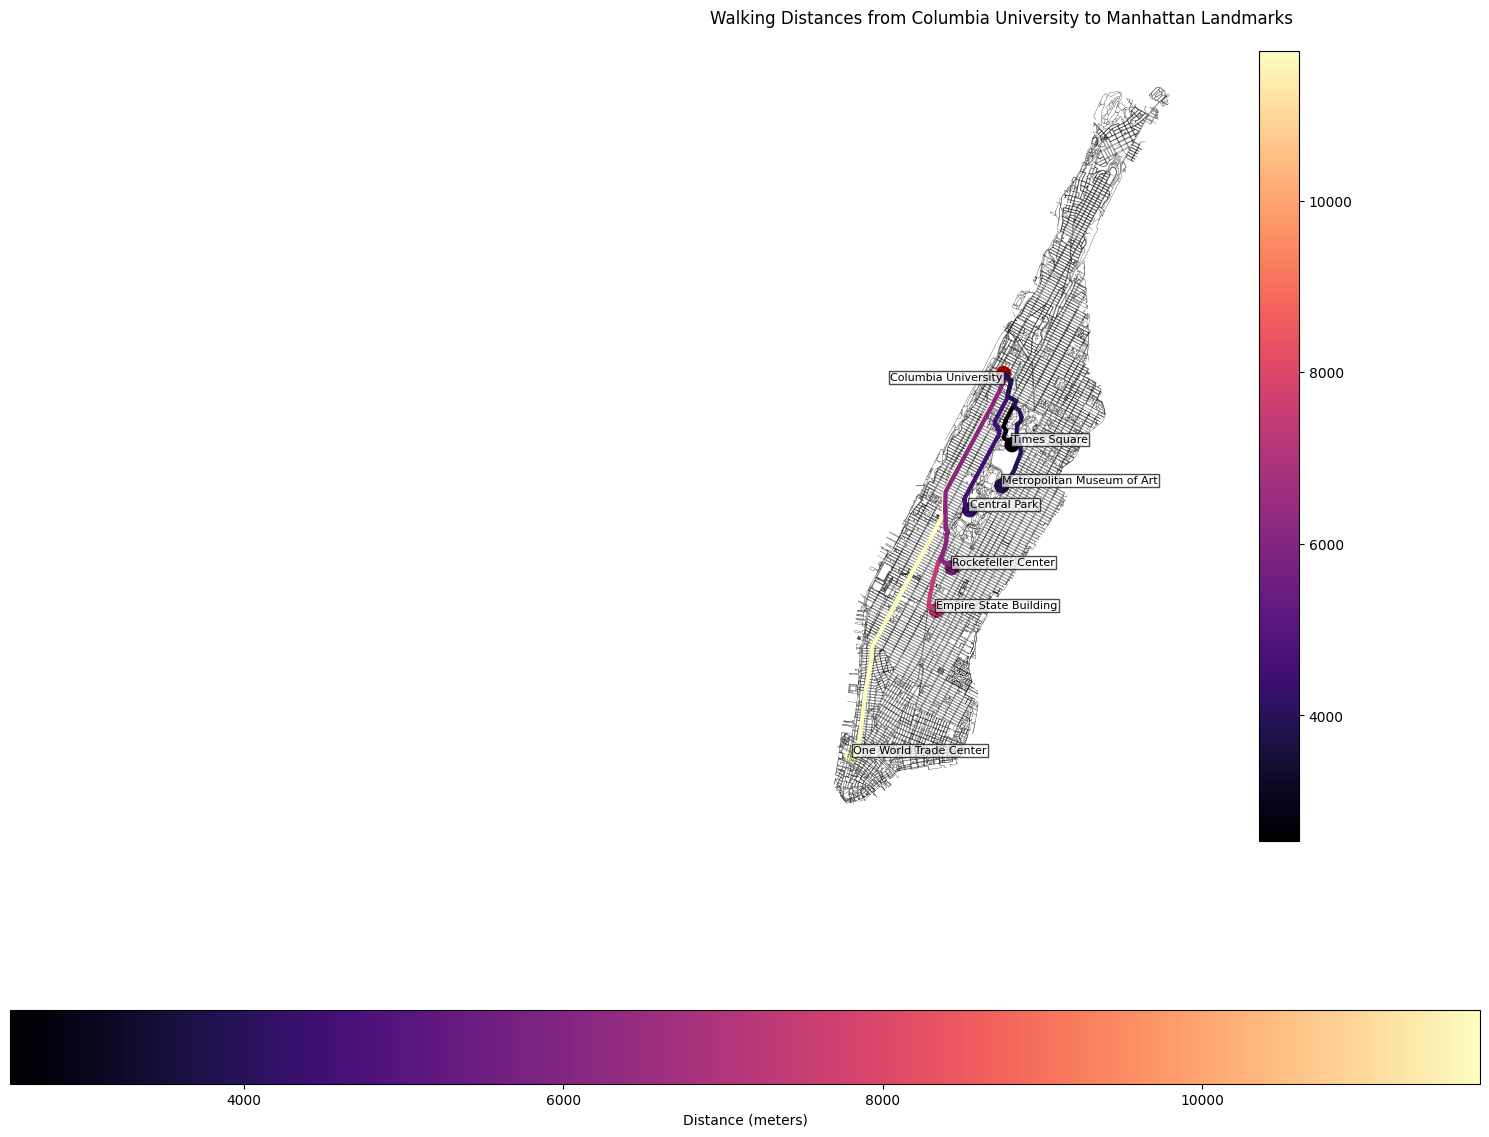


Distances from Columbia University:
                         name      distance
1                Times Square   2537.342062
5  Metropolitan Museum of Art   3919.437114
2                Central Park   4468.520521
4          Rockefeller Center   6129.866199
0       Empire State Building   7406.084524
3      One World Trade Center  11740.106106


In [44]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, LineString
import pandas as pd

# Configure OSMnx
ox.settings.log_console = True
ox.settings.use_cache = True

# Define origin (Columbia University) as (lon, lat)
origin_name = "Columbia University"
columbia_point = (-73.9626, 40.8075)

# Get Manhattan street network
print("Downloading Manhattan street network...")
G = ox.graph_from_place("Manhattan, New York, USA", network_type='walk', simplify=True)
G_projected = ox.project_graph(G)
graph_crs = ox.graph_to_gdfs(G_projected, edges=False).crs

# Create landmarks with (lon, lat)
landmarks = {
    'name': [
        'Empire State Building',
        'Times Square',
        'Central Park',
        'One World Trade Center',
        'Rockefeller Center',
        'Metropolitan Museum of Art'
    ],
    'geometry': [
        Point(-73.9853, 40.74865),    # Empire State
        Point(-73.95989, 40.78962),   # Times Square
        Point(-73.97399, 40.77357),   # Central Park
        Point(-74.01304, 40.71295),   # One WTC
        Point(-73.97996, 40.75926),   # Rockefeller
        Point(-73.96338, 40.77944)    # Met Museum
    ]
}

# Create GeoDataFrame and project to graph's CRS
gdf = gpd.GeoDataFrame(landmarks, crs="EPSG:4326")
gdf_proj = gdf.to_crs(graph_crs)

# Project origin point
origin_geom = gpd.GeoDataFrame(
    geometry=[Point(columbia_point)], 
    crs="EPSG:4326"
).to_crs(graph_crs).geometry[0]

# Get nearest nodes
origin_node = ox.distance.nearest_nodes(
    G_projected, 
    origin_geom.x, 
    origin_geom.y
)

# Calculate shortest paths and distances
routes = []
for idx, row in gdf_proj.iterrows():
    try:
        # Get nearest node for landmark
        dest_node = ox.distance.nearest_nodes(
            G_projected, 
            row.geometry.x, 
            row.geometry.y
        )
        
        # Get shortest path
        path = nx.shortest_path(
            G_projected, 
            origin_node, 
            dest_node, 
            weight='length'
        )
        
        # Calculate path length in meters
        path_length = nx.shortest_path_length(
            G_projected, 
            origin_node, 
            dest_node, 
            weight='length'
        )
        
        # Create LineString for the path
        path_coords = [(G_projected.nodes[n]['x'], G_projected.nodes[n]['y']) for n in path]
        route_line = LineString(path_coords)
        
        routes.append({
            'name': row['name'],
            'geometry': route_line,
            'distance': path_length
        })
        
    except Exception as e:
        print(f"Could not find path to {row['name']}: {e}")

# Create GeoDataFrames for plotting
routes_gdf = gpd.GeoDataFrame(routes, crs=graph_crs)
gdf_proj['distance'] = gdf_proj['name'].map({r['name']: r['distance'] for r in routes})

# Create figure
fig, ax = plt.subplots(figsize=(15, 12))

# Plot the network edges
edges = ox.graph_to_gdfs(G_projected, nodes=False)
edges.plot(ax=ax, color='black', linewidth=0.1)

# Plot the routes, colored by distance
routes_gdf.plot(
    column='distance', 
    cmap='magma', 
    ax=ax, 
    linewidth=3,
    legend=True,
    legend_kwds={'label': "Distance (meters)", 'orientation': "horizontal"}
)

# Plot the landmarks, colored by distance
gdf_proj.plot(
    column='distance',
    cmap='magma',
    markersize=100,
    ax=ax,
    legend=True
)

# Add labels
for x, y, label in zip(gdf_proj.geometry.x, gdf_proj.geometry.y, gdf_proj.name):
    ax.text(x, y, label, fontsize=8, ha='left', va='bottom',
           bbox=dict(facecolor='white', alpha=0.7, pad=1))

# Plot and label origin
ax.scatter(
    origin_geom.x, 
    origin_geom.y, 
    color='red', 
    s=100, 
    label=origin_name
)
ax.text(
    origin_geom.x, 
    origin_geom.y, 
    origin_name, 
    fontsize=8, 
    ha='right', 
    va='top',
    bbox=dict(facecolor='white', alpha=0.7, pad=1)
)

# Add title and adjust layout
plt.title(f"Walking Distances from {origin_name} to Manhattan Landmarks", pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print distances
print("\nDistances from Columbia University:")
print(gdf_proj[['name', 'distance']].sort_values('distance'))